In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pycountry
import requests
import time
import plotly.express as px
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score
import statsmodels.api as sm
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import StratifiedKFold
import statsmodels.api as sm
from sklearn.utils import resample

In [4]:
german = pd.read_csv("german_credit.csv")

In [5]:
german

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,no checking account,18,all credits at this bank paid back duly,car (used),1049,unknown/no savings account,< 1 yr,< 20,female : non-single or male : single,none,...,car or other,21,none,for free,1,skilled employee/official,0 to 2,no,no,good
1,no checking account,9,all credits at this bank paid back duly,others,2799,unknown/no savings account,1 <= ... < 4 yrs,25 <= ... < 35,male : married/widowed,none,...,unknown / no property,36,none,for free,3-Feb,skilled employee/official,3 or more,no,no,good
2,... < 0 DM,12,no credits taken/all credits paid back duly,retraining,841,... < 100 DM,4 <= ... < 7 yrs,25 <= ... < 35,female : non-single or male : single,none,...,unknown / no property,23,none,for free,1,unskilled - resident,0 to 2,no,no,good
3,no checking account,12,all credits at this bank paid back duly,others,2122,unknown/no savings account,1 <= ... < 4 yrs,20 <= ... < 25,male : married/widowed,none,...,unknown / no property,39,none,for free,3-Feb,unskilled - resident,3 or more,no,yes,good
4,no checking account,12,all credits at this bank paid back duly,others,2171,unknown/no savings account,1 <= ... < 4 yrs,< 20,male : married/widowed,none,...,car or other,38,bank,rent,3-Feb,unskilled - resident,0 to 2,no,yes,good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,no checking account,24,no credits taken/all credits paid back duly,furniture/equipment,1987,unknown/no savings account,1 <= ... < 4 yrs,25 <= ... < 35,male : married/widowed,none,...,unknown / no property,21,none,for free,1,unskilled - resident,3 or more,no,no,bad
996,no checking account,24,no credits taken/all credits paid back duly,others,2303,unknown/no savings account,>= 7 yrs,< 20,male : married/widowed,co-applicant,...,unknown / no property,45,none,rent,1,skilled employee/official,0 to 2,no,no,bad
997,... >= 200 DM / salary for at least 1 year,21,all credits at this bank paid back duly,others,12680,... >= 1000 DM,>= 7 yrs,< 20,male : married/widowed,none,...,real estate,30,none,own,1,manager/self-empl./highly qualif. employee,0 to 2,yes (under customer name),no,bad
998,... < 0 DM,12,no credits taken/all credits paid back duly,furniture/equipment,6468,... >= 1000 DM,unemployed,25 <= ... < 35,male : married/widowed,none,...,real estate,52,none,rent,1,manager/self-empl./highly qualif. employee,0 to 2,yes (under customer name),no,bad


In [6]:
german.isna().sum()

status                     0
duration                   0
credit_history             0
purpose                    0
amount                     0
savings                    0
employment_duration        0
installment_rate           0
personal_status_sex        0
other_debtors              0
present_residence          0
property                   0
age                        0
other_installment_plans    0
housing                    0
number_credits             0
job                        0
people_liable              0
telephone                  0
foreign_worker             0
credit_risk                0
dtype: int64

In [7]:
german.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   status                   1000 non-null   object
 1   duration                 1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   amount                   1000 non-null   int64 
 5   savings                  1000 non-null   object
 6   employment_duration      1000 non-null   object
 7   installment_rate         1000 non-null   object
 8   personal_status_sex      1000 non-null   object
 9   other_debtors            1000 non-null   object
 10  present_residence        1000 non-null   object
 11  property                 1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

In [8]:
german.describe(include='all')

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
count,1000,1000.000000,1000,1000,1000.00000,1000,1000,1000,1000,1000,...,1000,1000.00000,1000,1000,1000,1000,1000,1000,1000,1000
unique,4,NaN,5,10,NaN,5,5,4,4,3,...,4,NaN,3,3,4,4,2,2,2,2
top,... >= 200 DM / salary for at least 1 year,NaN,no credits taken/all credits paid back duly,furniture/equipment,NaN,unknown/no savings account,1 <= ... < 4 yrs,< 20,male : married/widowed,none,...,building soc. savings agr./life insurance,NaN,none,rent,1,skilled employee/official,0 to 2,no,no,good
freq,394,NaN,530,280,NaN,603,339,476,548,907,...,332,NaN,814,714,633,630,845,596,963,700
mean,NaN,20.903000,NaN,NaN,3271.24800,NaN,NaN,NaN,NaN,NaN,...,NaN,35.54200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,12.058814,NaN,NaN,2822.75176,NaN,NaN,NaN,NaN,NaN,...,NaN,11.35267,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,4.000000,NaN,NaN,250.00000,NaN,NaN,NaN,NaN,NaN,...,NaN,19.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,12.000000,NaN,NaN,1365.50000,NaN,NaN,NaN,NaN,NaN,...,NaN,27.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,18.000000,NaN,NaN,2319.50000,NaN,NaN,NaN,NaN,NaN,...,NaN,33.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,24.000000,NaN,NaN,3972.25000,NaN,NaN,NaN,NaN,NaN,...,NaN,42.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Most of the feature are categorial, so we will have to use function as "one-hot-encoding" to create the model

Number_credits is wrong labeled, so let's change it

In [9]:
german['number_credits'] = german['number_credits'].replace({'3-Feb': '2-3', '5-Apr': '4-5'})

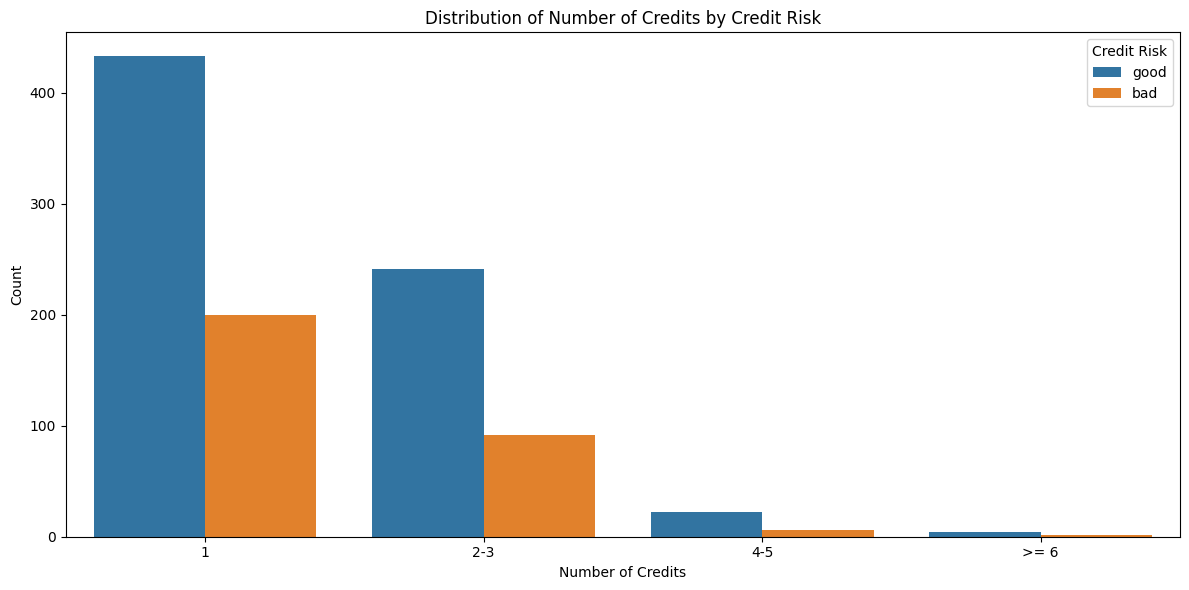

In [10]:
plt.figure(figsize=(12,6))
order = german['number_credits'].value_counts().index
sns.countplot(data=german, x='number_credits', hue='credit_risk', order=order)
plt.xlabel('Number of Credits')
plt.ylabel('Count')
plt.title('Distribution of Number of Credits by Credit Risk')
plt.legend(title='Credit Risk')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Age Distribution')

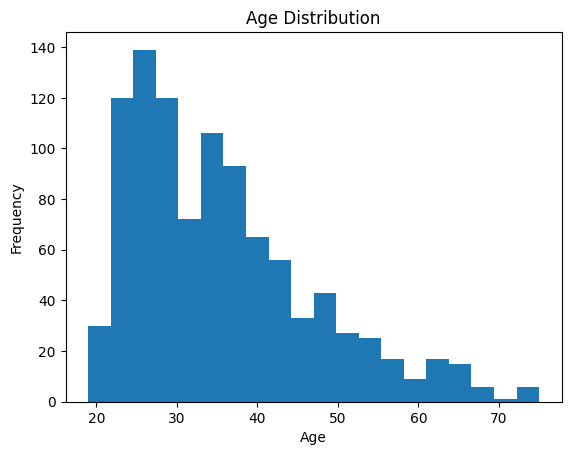

In [11]:
plt.hist(german['age'], bins=20)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')

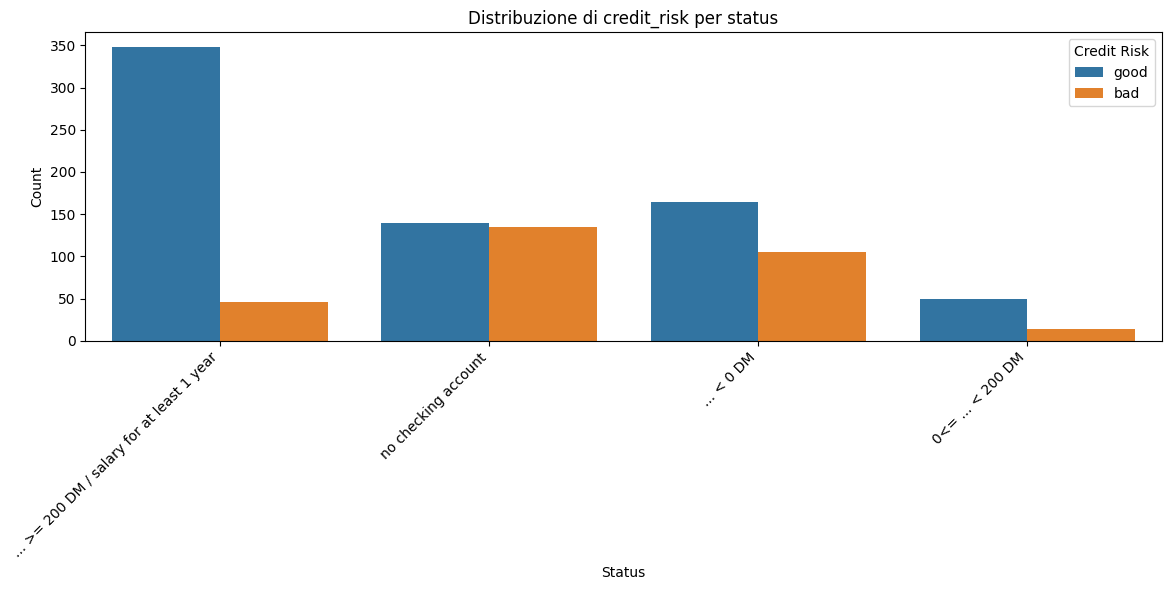

In [12]:
# Grafico: confronto tra 'status' e 'credit_risk'
plt.figure(figsize=(12,6))
order = german['status'].value_counts().index
sns.countplot(data=german, x='status', hue='credit_risk', order=order)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Status')
plt.ylabel('Count')
plt.title('Distribuzione di credit_risk per status')
plt.legend(title='Credit Risk')
plt.tight_layout()
plt.show()

The categoric features have 3/4 distinct values in average. 

Seeing the feature there is one called "purpose", with a lot of distinct values.

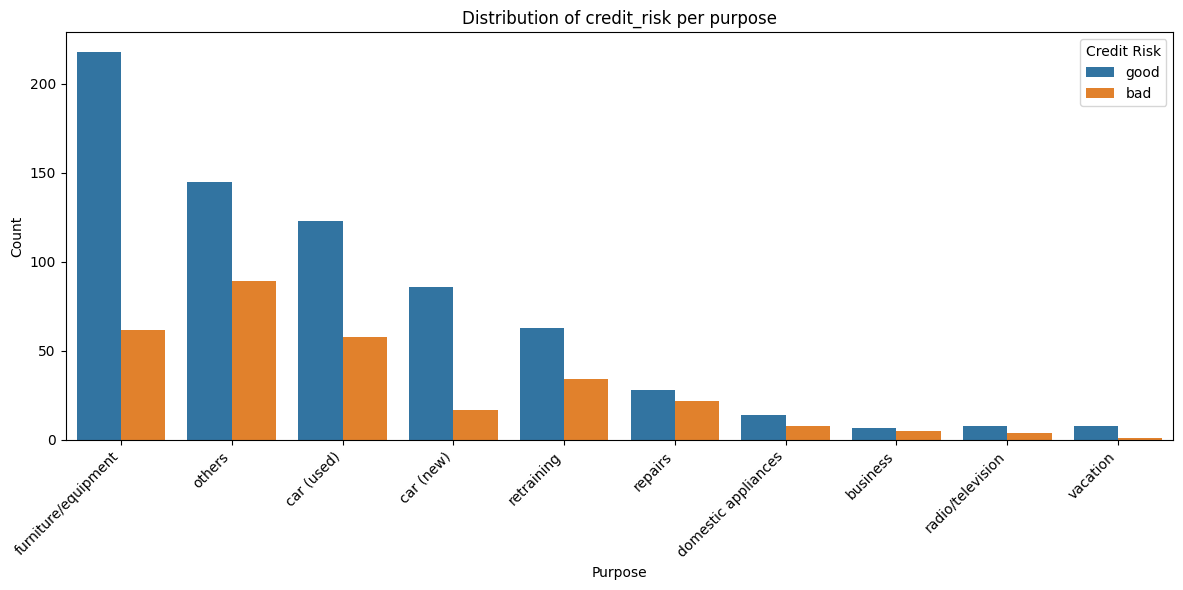

In [13]:
# Grafico: confronto tra 'status' e 'credit_risk'
plt.figure(figsize=(12,6))
order = german['purpose'].value_counts().index
sns.countplot(data=german, x='purpose', hue='credit_risk', order=order)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Purpose')
plt.ylabel('Count')
plt.title('Distribution of credit_risk per purpose')
plt.legend(title='Credit Risk')
plt.tight_layout()
plt.show()

In [14]:
german_encoded = pd.get_dummies(german, columns=["status",
    "credit_history",
    "purpose",
    "savings",
    "personal_status_sex",
    "other_debtors",
    "other_installment_plans",
    "housing",
    "telephone",
    "foreign_worker", "employment_duration",
    "installment_rate",
    "present_residence",
    "property",
    "number_credits",
    "job",
    "people_liable"], drop_first=True)


In [15]:
X = german_encoded.drop('credit_risk', axis=1)
y = german_encoded['credit_risk'].map({'good':0, 'bad':1})

bool_cols = X.select_dtypes(include=['bool']).columns
X[bool_cols] = X[bool_cols].replace({True: 1, False: 0})

C:\Users\franc\AppData\Local\Temp\ipykernel_22112\243181083.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[bool_cols] = X[bool_cols].replace({True: 1, False: 0})


In [16]:
X1 = sm.add_constant(X)
logit_model = sm.Logit(y, X1)
result = logit_model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.446479
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:            credit_risk   No. Observations:                 1000
Model:                          Logit   Df Residuals:                      945
Method:                           MLE   Df Model:                           54
Date:                Sat, 20 Dec 2025   Pseudo R-squ.:                  0.2691
Time:                        16:34:59   Log-Likelihood:                -446.48
converged:                       True   LL-Null:                       -610.86
Covariance Type:            nonrobust   LLR p-value:                 4.890e-41
                                                                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------
const       

In [17]:
y_pred = (result.predict(X1) >= 0.5).astype(int)

accuracy = accuracy_score(y, y_pred)
print("Accuracy of Logistic Model:", accuracy)

Accuracy of Logistic Model: 0.787


In [18]:
model_names = ["Logit Full", "Logit Limited", "Treshold Tuning", "Lasso"]

df_models = pd.DataFrame(index=model_names)

# LOGIT FULL

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols]  = X_test[bool_cols].astype(int)

X_train_const = sm.add_constant(X_train)
logit_model = sm.Logit(y_train, X_train_const)
result = logit_model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.424492
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:            credit_risk   No. Observations:                  750
Model:                          Logit   Df Residuals:                      695
Method:                           MLE   Df Model:                           54
Date:                Sat, 20 Dec 2025   Pseudo R-squ.:                  0.3051
Time:                        16:34:59   Log-Likelihood:                -318.37
converged:                       True   LL-Null:                       -458.15
Covariance Type:            nonrobust   LLR p-value:                 3.623e-32
                                                                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------
const       

let's see which features have the greatest impact in terms of coefficients

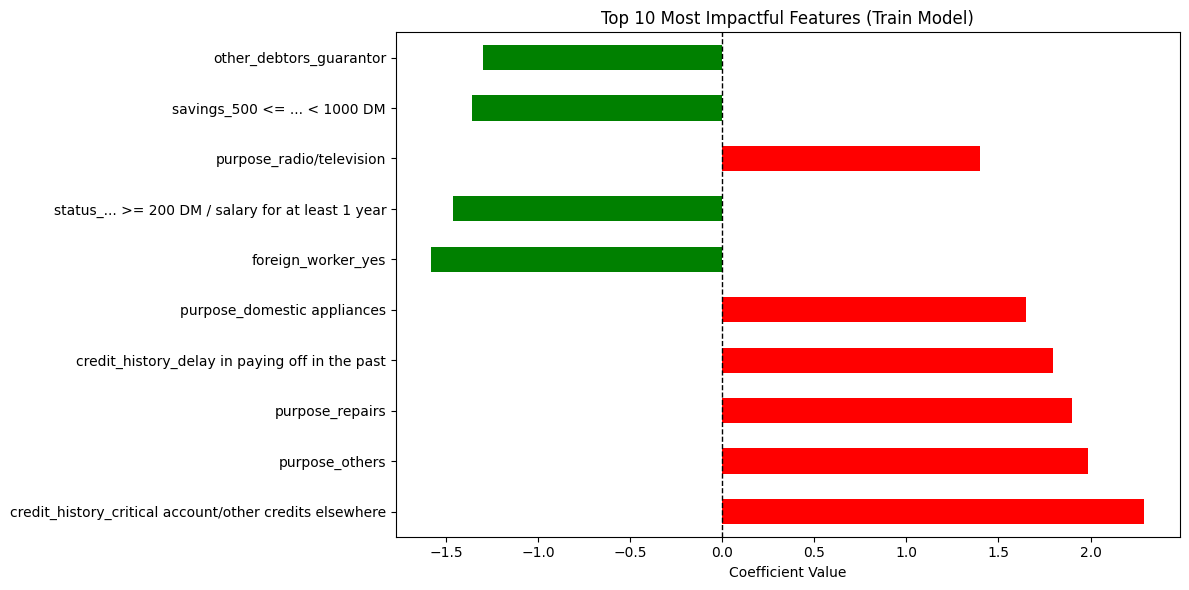


=== KEY INSIGHTS ===
1. credit_history_critical account/other credits elsewhere: β=2.292, OR=9.90
2. purpose_others: β=1.987, OR=7.30


In [20]:
coefs = pd.DataFrame({
    'Coefficient': result.params[1:],      
    'Std_Error': result.bse[1:],
    'Z_score': result.tvalues[1:],
    'P_value': result.pvalues[1:],
    'Odds_Ratio': np.exp(result.params[1:])  
}, index=result.params.index[1:])

top_impact = coefs.reindex(
    coefs['Coefficient'].abs().sort_values(ascending=False).index[:10]
)

plt.figure(figsize=(12, 6))
top_impact['Coefficient'].plot(kind='barh',  
                              capsize=5, 
                              color=['red' if x > 0 else 'green' for x in top_impact['Coefficient']])
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Coefficient Value')
plt.title('Top 10 Most Impactful Features (Train Model)')
plt.tight_layout()
plt.show()


print(f"\n=== KEY INSIGHTS ===")
print(f"1. {top_impact.index[0]}: β={top_impact['Coefficient'].iloc[0]:.3f}, OR={top_impact['Odds_Ratio'].iloc[0]:.2f}")
print(f"2. {top_impact.index[1]}: β={top_impact['Coefficient'].iloc[1]:.3f}, OR={top_impact['Odds_Ratio'].iloc[1]:.2f}")

The bar chart shows the top 10 features ranked by coefficient magnitude (β) impact on credit risk. 

The horizontal axis displays logit coefficients where positive values (red bars) increase default risk, while negative values (green bars) decrease it.

Having a critical credit history (problems with past credits elsewhere) dramatically increases default risk with OR=9.90 (nearly 10x higher odds), while loans for unspecified purposes also elevate risk significantly (OR=7.30). Conversely, being a foreign worker reduces risk (OR=0.25, 75% lower odds), and having a high salary account (status <0 DM) strongly protects against default (OR=0.23).

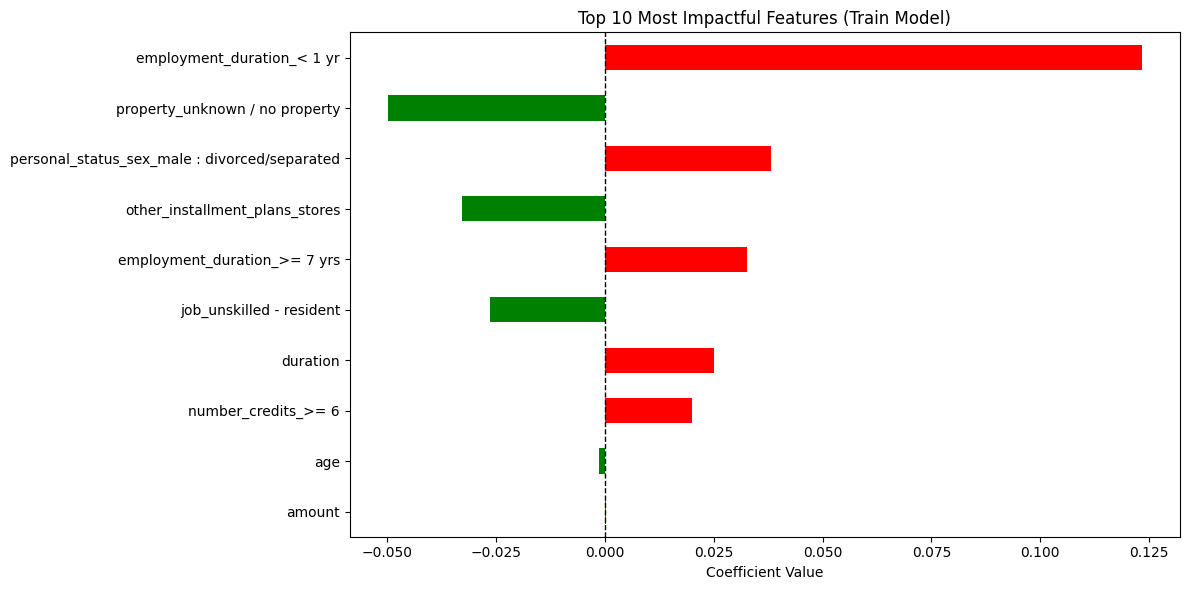

In [21]:
coefs = pd.DataFrame({
    'Coefficient': result.params[1:],      
    'Std_Error': result.bse[1:],
    'Z_score': result.tvalues[1:],
    'P_value': result.pvalues[1:],
    'Odds_Ratio': np.exp(result.params[1:])  
}, index=result.params.index[1:])

less_impact = coefs.reindex(
    coefs['Coefficient'].abs().sort_values(ascending=True).index[:10]
)

plt.figure(figsize=(12, 6))
less_impact['Coefficient'].plot(kind='barh',  
                              capsize=5, 
                              color=['red' if x > 0 else 'green' for x in less_impact['Coefficient']])
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Coefficient Value')
plt.title('Top 10 Most Impactful Features (Train Model)')
plt.tight_layout()
plt.show()

Here the ten most impactful features in terms of their coefficients are shown.

Interestingly, loan amount and age have coefficients very close to zero, which means they have almost no effect on the model’s prediction of bad credit risk, 
despite being variables that might intuitively be expected to matter.

## Prediction

Train Accuracy: 0.7973
Test Accuracy:  0.7240


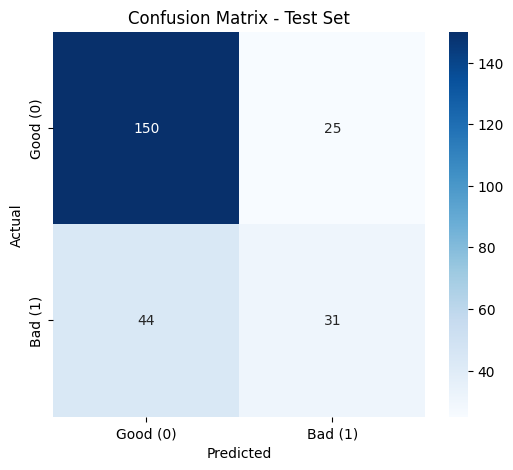

Test F1-score:  0.4733
              precision    recall  f1-score   support

    Good (0)       0.77      0.86      0.81       175
     Bad (1)       0.55      0.41      0.47        75

    accuracy                           0.72       250
   macro avg       0.66      0.64      0.64       250
weighted avg       0.71      0.72      0.71       250



In [22]:
X_test_const = sm.add_constant(X_test)
y_pred_prob = result.predict(X_test_const)
y_pred = (y_pred_prob >= 0.5).astype(int)

print(f"Train Accuracy: {accuracy_score(y_train, (result.predict(X_train_const)>=0.5).astype(int)):.4f}")
print(f"Test Accuracy:  {accuracy_score(y_test, y_pred):.4f}")

cm1 = confusion_matrix(y_test, y_pred)
labels = ['Good (0)', 'Bad (1)']
plt.figure(figsize=(6,5))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Test Set')
plt.show()

print(f"Test F1-score:  {f1_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, target_names=['Good (0)', 'Bad (1)']))

df_models.loc["Logit Full", "Test Accuracy"] = round(accuracy_score(y_test, y_pred),3)
df_models.loc["Logit Full", "Test F1-score"] = round(f1_score(y_test, y_pred),3)   
df_models.loc["Logit Full", "Recall"] = round(recall_score(y_test, y_pred),3)

This confusion matrix summarizes performance on the test set: overall accuracy is about 72%, with 150 good clients correctly classified, 25 good misclassified as bad, 31 bad correctly detected, and 44 bad misclassified as good (test F1-score ≈ 0.47 for the bad class).​

From a credit risk perspective, the key number is the recall for the bad class, which is only 0.41: the model identifies about 41% of truly risky customers, while 59% of bad credits slip through as good. Since the project aims to minimize bad credits even at the cost of some overall accuracy, this plot motivates shifting the decision threshold: sacrificing some correct “good” predictions to increase bad‑class recall and reduce undetected risky loans.

# LOGIT LIMITED 
#### Since there are a lot of features and a lot of them probably have small p-value, let's take only the features with a p-value < 0.1

In [23]:
X_limited = [col for col in X.columns if result.pvalues[col] < 0.1]

In [24]:
X_train_lim, X_test_lim, y_train_lim, y_test_lim = train_test_split(
    X[X_limited], y, test_size=0.25, random_state=42, stratify=y)

X_train_const_lim = sm.add_constant(X_train_lim)
logit_model_lim = sm.Logit(y_train_lim, X_train_const_lim)
result_lim = logit_model_lim.fit()

print(result_lim.summary())

Optimization terminated successfully.
         Current function value: 0.456254
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:            credit_risk   No. Observations:                  750
Model:                          Logit   Df Residuals:                      730
Method:                           MLE   Df Model:                           19
Date:                Sat, 20 Dec 2025   Pseudo R-squ.:                  0.2531
Time:                        16:35:00   Log-Likelihood:                -342.19
converged:                       True   LL-Null:                       -458.15
Covariance Type:            nonrobust   LLR p-value:                 1.390e-38
                                                                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------
const       

coefficients seems quite similar to the previous ones

Train Accuracy: 0.7907
Test Accuracy:  0.7520


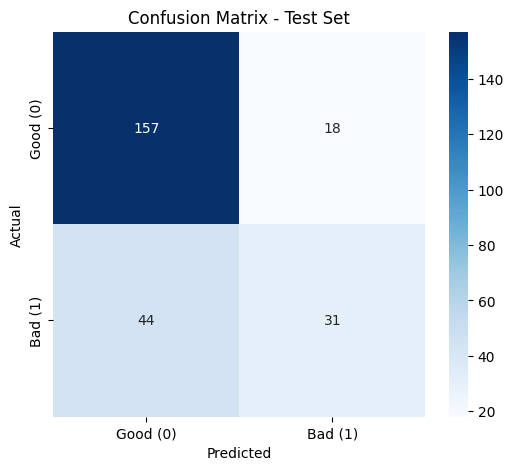

Test F1-score:  0.5000
              precision    recall  f1-score   support

    Good (0)       0.78      0.90      0.84       175
     Bad (1)       0.63      0.41      0.50        75

    accuracy                           0.75       250
   macro avg       0.71      0.66      0.67       250
weighted avg       0.74      0.75      0.73       250



In [25]:
X_test_const_lim = sm.add_constant(X_test_lim)
y_pred_prob_lim = result_lim.predict(X_test_const_lim)
y_pred_lim = (y_pred_prob_lim >= 0.5).astype(int)

print(f"Train Accuracy: {accuracy_score(y_train_lim, (result_lim.predict(X_train_const_lim)>=0.5).astype(int)):.4f}")
print(f"Test Accuracy:  {accuracy_score(y_test_lim, y_pred_lim):.4f}")

cm = confusion_matrix(y_test_lim, y_pred_lim)
labels = ['Good (0)', 'Bad (1)']
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Test Set')
plt.show()

print(f"Test F1-score:  {f1_score(y_test_lim, y_pred_lim):.4f}")
print(classification_report(y_test_lim, y_pred_lim, target_names=['Good (0)', 'Bad (1)']))

df_models.loc["Logit Limited", "Test Accuracy"] = round(accuracy_score(y_test_lim, y_pred_lim),3)
df_models.loc["Logit Limited", "Test F1-score"] = round(f1_score(y_test_lim, y_pred_lim),3)   
df_models.loc["Logit Limited", "Recall"] = round(recall_score(y_test_lim, y_pred_lim),3)

By removing all predictors with p-values exceeding 0.1, we obtain a more parsimonious model that retains predictive power. The simplified model achieves a test accuracy of 75%, an improvement over the full model's 72%, while maintaining identical recall on the bad class at 41%. This demonstrates that we can eliminate statistically insignificant noise without sacrificing sensitivity to credit risk, resulting in a cleaner, more interpretable specification for credit risk assessment.

In [26]:
print("Number of full model features:", X1.shape[1])
print("Number of limited model features:", len(X_limited))

Number of full model features: 55
Number of limited model features: 19


As we can see, most predictors are not statistically significant at the 10% level, infact we reduced the number from 55 to 19 variables.

## Likelihood ratio test

To be sure of this sentence, we'll perform a likelihood ratio test comparing the full and the reduced specification. A p‑value below 0.05 indicates that the additional predictors in the full model significantly improve the fit; otherwise, the simpler limited model is statistically sufficient.

In [27]:
from scipy.stats import chi2
full_llf = result.llf
lim_llf  = result_lim.llf

# Difference in number of parameters
df_diff = result.df_model - result_lim.df_model

# Likelihood Ratio statistic
lr_stat = 2 * (full_llf - lim_llf)

# p-value from chi-square distribution
p_value = chi2.sf(lr_stat, df_diff)

print(f"LR statistic: {lr_stat:.3f}")
print(f"df difference: {df_diff}")
print(f"LR test p-value: {p_value:.4f}")

LR statistic: 47.643
df difference: 35.0
LR test p-value: 0.0753


As a result, we obtained a p‑value of 0.07 that means that, at the usual 5% level, the reduced model is sufficient: the full model does not improve the fit in a statistically significant way. 

## Threshold Tuning CLASSIFICATION 

Since predicting bad clients good is much worse than doing the opposite, we will find a treshold, trying to reach a good compromise between accuracy and recall

In [28]:
p_test = result.predict(X_test_const)

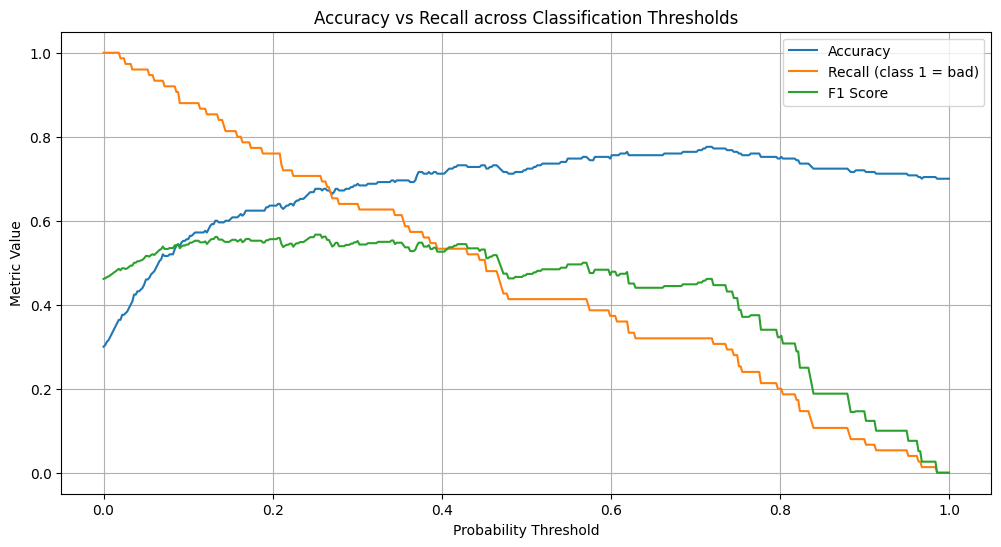

In [29]:
thresholds = np.linspace(0, 1, 500)

accuracies = []
recalls = []
f1_scores = []

for t in thresholds:
    y_pred = (p_test >= t).astype(int)
    accuracies.append(accuracy_score(y_test, y_pred))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))

plt.figure(figsize=(12,6))

plt.plot(thresholds, accuracies, label="Accuracy")
plt.plot(thresholds, recalls, label="Recall (class 1 = bad)")
plt.plot(thresholds, f1_scores, label="F1 Score")

plt.xlabel("Probability Threshold")
plt.ylabel("Metric Value")
plt.title("Accuracy vs Recall across Classification Thresholds")
plt.legend()
plt.grid(True)

plt.show()

We can see that the best threshold that gives us a good value of accuracy and recall is around 0.25, so we can predict the model using this threshold and observe the correlation matrix

Train Accuracy: 0.7973
Test Accuracy:  0.6720


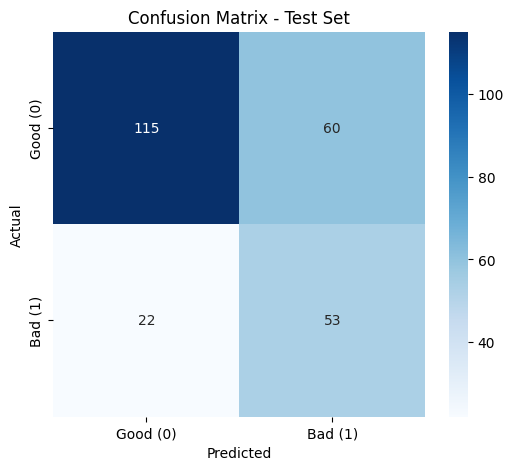

Test F1-score:  0.5638
              precision    recall  f1-score   support

    Good (0)       0.84      0.66      0.74       175
     Bad (1)       0.47      0.71      0.56        75

    accuracy                           0.67       250
   macro avg       0.65      0.68      0.65       250
weighted avg       0.73      0.67      0.69       250



In [30]:
y_pred_tres = (y_pred_prob >= 0.25).astype(int)

print(f"Train Accuracy: {accuracy_score(y_train, (result.predict(X_train_const)>=0.5).astype(int)):.4f}")
print(f"Test Accuracy:  {accuracy_score(y_test, y_pred_tres):.4f}")

cm_tres = confusion_matrix(y_test, y_pred_tres)
plt.figure(figsize=(6,5))
sns.heatmap(cm_tres, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Test Set')
plt.show()

print(f"Test F1-score:  {f1_score(y_test, y_pred_tres):.4f}")
print(classification_report(y_test, y_pred_tres, target_names=['Good (0)', 'Bad (1)']))

df_models.loc["Treshold Tuning", "Test Accuracy"] = round(accuracy_score(y_test, y_pred_tres),3)
df_models.loc["Treshold Tuning", "Test F1-score"] = round(f1_score(y_test, y_pred_tres),3)   
df_models.loc["Treshold Tuning", "Recall"] = round(recall_score(y_test, y_pred_tres),3)

This model uses a lower probability threshold of 0.25, which makes the classifier more aggressive in labeling clients as bad credit risks. As a result, test accuracy drops from about 75% to 67%, but the recall for bad credits increases from 0.41 to 0.71 , meaning the model now correctly flags 71% of truly risky customers at the cost of misclassifying more good clients.

# Lasso Regression

Since there are a lot of features, with most of them are categorical so it can create multicollinearity and also eliminating some of them seems to improve the results of the prediction, we'll use lasso regression in order to do a better feature selection

Using a relatively large alpha in Lasso has three main advantages:

- Stronger regularization and feature selection: A larger alpha increases the L1 penalty, shrinking many coefficients exactly to zero and leaving a smaller, more interpretable set of truly relevant predictors.

- Lower overfitting risk: With many features and limited data, stronger regularization increases bias but substantially reduces variance, making predictions more stable on new clients.

- Handling multicollinearity: When several variables are highly correlated (e.g. status, purpose, employment dummies), a larger alpha encourages the model to keep only one of them, simplifying the structure and avoiding large, unstable coefficients that cancel each other out.

To utilize lasso regression we need to standardize data, otherwise the coefficient will be penalized differently

In [31]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

we'll use a really strong alpha because there are a lot of features that are not really significative as we saw before, so we want to create a less weight model and bring more coefficients to 0

In [32]:
lasso = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    C=0.1,
    max_iter=10000
)
lasso.fit(X_train_scaled, y_train)

#print("Best C:", round(lasso.C_[0],2))

,penalty,'l1'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,10000
,multi_class,'deprecated'


In [33]:
print("Corresponding alpha:", round(1 / 0.1,4))

Corresponding alpha: 10.0


we'll use this alpha to create the model (around 10)

Test Accuracy: 0.772
F1-score: 0.5365853658536586


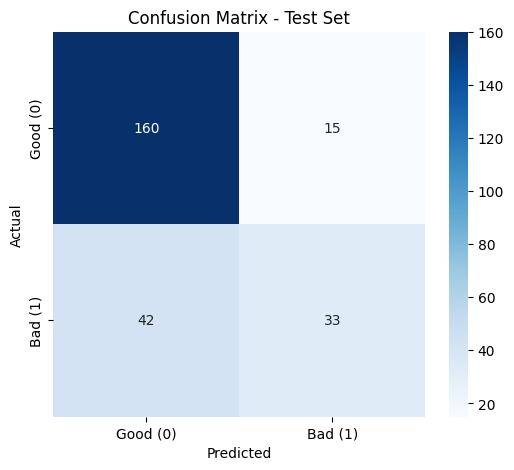

              precision    recall  f1-score   support

    Good (0)       0.79      0.91      0.85       175
     Bad (1)       0.69      0.44      0.54        75

    accuracy                           0.77       250
   macro avg       0.74      0.68      0.69       250
weighted avg       0.76      0.77      0.76       250



In [34]:
y_pred_lasso = lasso.predict(X_test_scaled)

print("Test Accuracy:", accuracy_score(y_test, y_pred_lasso))
print("F1-score:", f1_score(y_test, y_pred_lasso))

cm_lasso = confusion_matrix(y_test, y_pred_lasso)
plt.figure(figsize=(6,5))
sns.heatmap(cm_lasso, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Test Set')
plt.show()

print(classification_report(y_test, y_pred_lasso, target_names=['Good (0)', 'Bad (1)']))

df_models.loc["Lasso", "Test Accuracy"] = round(accuracy_score(y_test, y_pred_lasso),3)
df_models.loc["Lasso", "Test F1-score"] = round(f1_score(y_test, y_pred_lasso),3)   
df_models.loc["Lasso", "Recall"] = round(recall_score(y_test, y_pred_lasso),3)

This Lasso model achieves high overall test accuracy (77%) and a balanced performance across classes.​

On the test set, it correctly classifies 160 out of 175 good clients and 33 out of 75 bad clients, yielding a recall of 0.91 for good and 0.44 for bad, with an F1‑score of 0.54 on the bad class. Compared with the unregularized logit, Lasso slightly improves accuracy while keeping a similar recall on bad credits, but with a much sparser set of predictors, which supports the idea of a more stable and interpretable credit‑risk model.

In [35]:
coef = pd.Series(lasso.coef_[0], index=X.columns)

print("Zero coefficients:")
print(coef[coef == 0].sort_values())

Zero coefficients:
credit_history_existing credits paid back duly till now    0.0
purpose_car (used)                                         0.0
purpose_domestic appliances                                0.0
purpose_radio/television                                   0.0
purpose_retraining                                         0.0
purpose_vacation                                           0.0
savings_100 <= ... <  500 DM                               0.0
personal_status_sex_male : divorced/separated              0.0
other_debtors_none                                         0.0
other_installment_plans_stores                             0.0
housing_own                                                0.0
employment_duration_>= 7 yrs                               0.0
employment_duration_unemployed                             0.0
installment_rate_25 <= ... < 35                            0.0
present_residence_4 <= ... < 7 yrs                         0.0
property_car or other               

A lot of features were shrinked to 0, sign that we used a strong alpha and feature selection worked well

## BOOTSTRAP

Let's create bootstrap samples to estimate coefficients of lasso model because it is robust, non-parametric, there is multicollinearity, and the dataset is relatively small (e.g., around 1000 observations). Let's see if it works well or not

In [36]:
B = 500
coefs_boot = []

for i in range(B):
    
    idx = np.random.choice(len(X_train_scaled), size=len(X_train_scaled), replace=True)
    Xb = X_train_scaled[idx]
    yb = y_train.iloc[idx]

    try:
        model_b = LogisticRegression(
            penalty='l1',
            solver='liblinear',
            C=0.1,
            max_iter=10000
        ).fit(Xb, yb)

        coefs_boot.append(model_b.coef_[0])
    except:
        pass

coefs_boot = np.array(coefs_boot)

boot_mean = coefs_boot.mean(axis=0)
boot_se = coefs_boot.std(axis=0)
lower = np.percentile(coefs_boot, 2.5, axis=0)
upper = np.percentile(coefs_boot, 97.5, axis=0)

results_bootstrap_lasso = pd.DataFrame({
    "LASSO_coef": coef,
    "Boot_mean": boot_mean,
    "Boot_SE": boot_se,
    "Boot_CI_2.5%": lower,
    "Boot_CI_97.5%": upper
}, index=X.columns)

results_bootstrap_lasso_rounded = results_bootstrap_lasso.round(4)
results_bootstrap_lasso_rounded

,LASSO_coef,Boot_mean,Boot_SE,Boot_CI_2.5%,Boot_CI_97.5%
duration,0.2606,0.2611,0.1129,0.0307,0.4703
amount,0.2140,0.2140,0.1218,0.0000,0.4548
age,-0.0057,-0.0394,0.0606,-0.2095,0.0000
status_... >= 200 DM / salary for at least 1 year,-0.5327,-0.5475,0.1113,-0.7611,-0.3376
status_0<= ... < 200 DM,-0.1205,-0.1254,0.0881,-0.3054,0.0000
status_no checking account,0.1427,0.1437,0.0908,0.0000,0.3202
credit_history_critical account/other credits elsewhere,0.2304,0.2434,0.0897,0.0563,0.4060
credit_history_delay in paying off in the past,0.1853,0.1872,0.0895,0.0000,0.3637
credit_history_existing credits paid back duly till now,0.0000,0.0130,0.0393,-0.0392,0.1175
credit_history_no credits taken/all credits paid back duly,0.1690,0.1861,0.0977,0.0000,0.3749


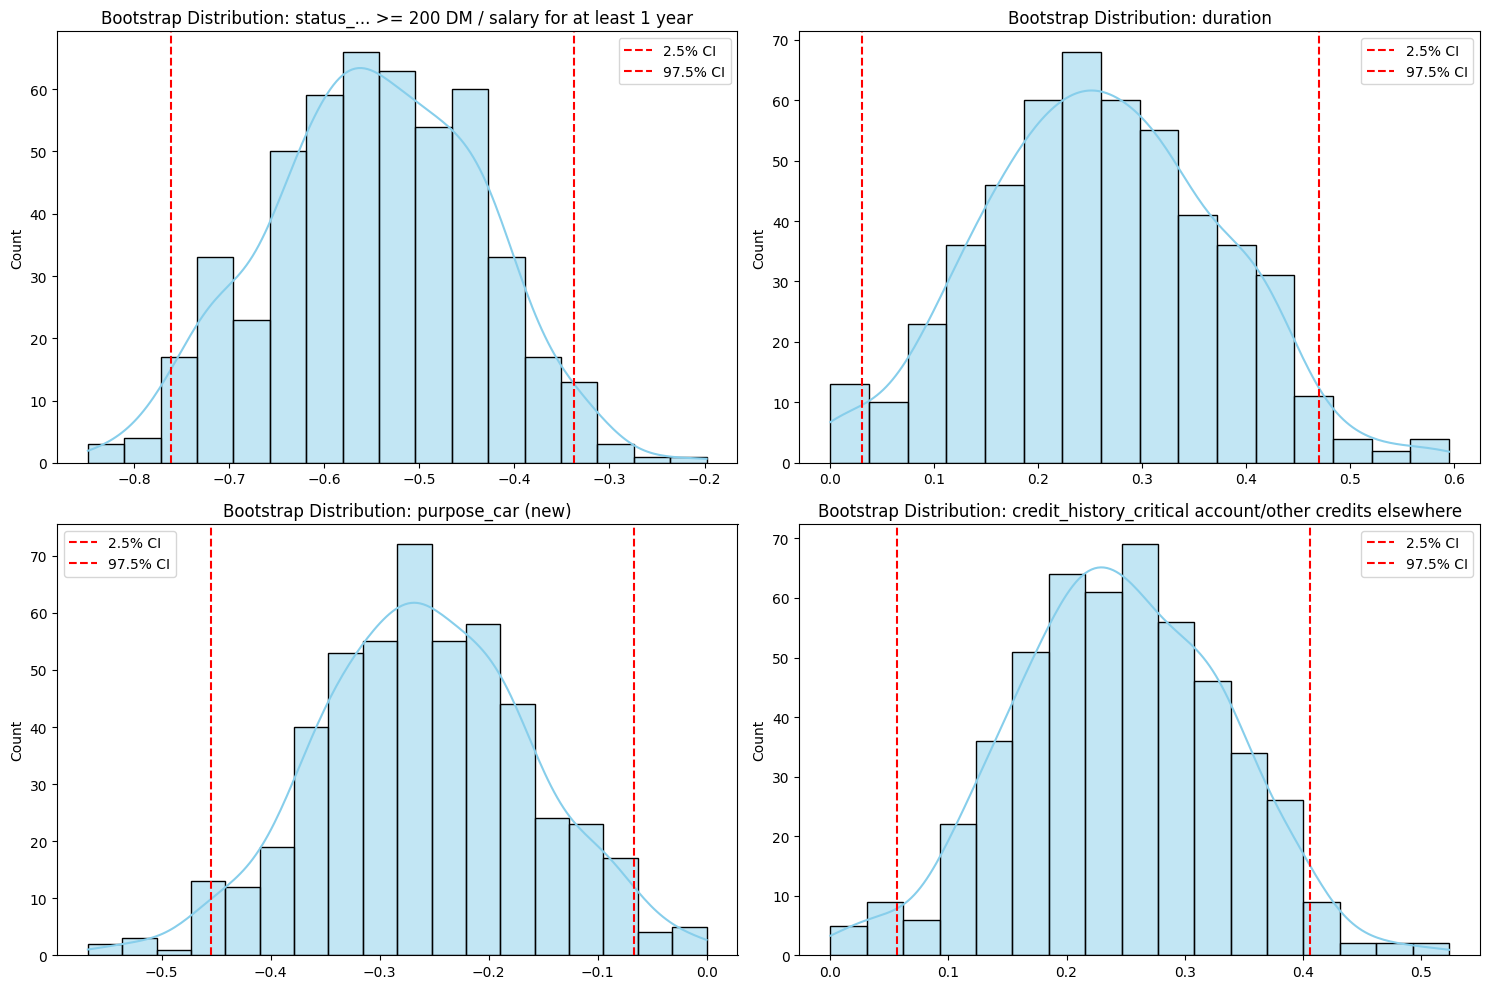

In [44]:
# Select the top 4 predictors by absolute coefficient size to visualize
top_predictors = results_bootstrap_lasso.abs().sort_values('LASSO_coef', ascending=False).head(4).index

plt.figure(figsize=(15, 10))
for i, col in enumerate(top_predictors):
    plt.subplot(2, 2, i+1)
    # Extract index of the column in the original X to get the bootstrap samples
    col_idx = list(X.columns).index(col)
    samples = coefs_boot[:, col_idx]
    
    sns.histplot(samples, kde=True, color='skyblue')
    plt.axvline(results_bootstrap_lasso.loc[col, 'Boot_CI_2.5%'], color='red', linestyle='--', label='2.5% CI')
    plt.axvline(results_bootstrap_lasso.loc[col, 'Boot_CI_97.5%'], color='red', linestyle='--', label='97.5% CI')
    plt.title(f'Bootstrap Distribution: {col}')
    plt.legend()

plt.tight_layout()
plt.show()

These histograms show the sampling distribution of our model’s most influential coefficients (duration, amount, status, etc.). Instead of a single number, they show the full range of values each predictor took across 500 different "versions" of our data created through bootstrap resampling. The red dashed lines mark the 95% confidence intervals.

Standard models assume the data follows a perfect "normal" distribution. We used a non-parametric bootstrap to bypass this assumption and let the data show its own uncertainty. This addresses the professor’s feedback by shifting from "point estimates" to statistical inference, allowing us to see which variables are actually reliable and which are just noisy.

**Statistical Analysis of Predictor Uncertainty (Bootstrap Distributions)**

To address the stability of our credit risk predictors, we move beyond simple point estimates and investigate the **empirical sampling distributions** of our primary coefficients. Using 500 non-parametric bootstrap replicates, we approximate the uncertainty of our model without assuming the data follows a perfect normal distribution.

**1. Analysis of the Sampling Distributions**

Based on the generated histograms, we can draw several key statistical insights:

* **Status (>= 200 DM / Salary):** This is the model's most robust predictor, centered at approximately $-0.55$. The distribution is symmetric and remains strictly negative within the $95\%$ confidence interval $[−0.76, −0.34]$, indicating high certainty that account liquidity reduces risk.
* **Duration:** The distribution shows a clear positive relationship with risk (centered at $0.26$). The $95\%$ interval $[0.03, 0.47]$ is entirely above zero, providing statistical evidence that longer-term loans consistently correlate with higher default probabilities.
* **Purpose (New Car):** While this is a top-four predictor, the right-hand confidence interval boundary ($-0.07$) is significantly closer to zero than the others. This suggests higher uncertainty; while the "point estimate" suggests it is a strong factor, the bootstrap reveals it is more sensitive to specific data samples.
* **Credit History (Critical Account):** The bell-shaped distribution centered at $0.23$ has an interval of $[0.06, 0.41]$. Since this does not include zero, we have statistical confidence that a critical credit history is a significant indicator of increased risk.

**2. Bias-Variance Tradeoff and Model Stability**

By choosing **LASSO (L1 Regularization)**, we have intentionally introduced a small amount of **Bias** into our estimates to significantly reduce the **Variance** of the overall model. This "Automatic Feature Selection" is what allowed us to isolate these four stable variables while shrinking less reliable features—such as loan amount—toward zero.

The fact that none of these top four distributions cross the zero line is the proof of their statistical significance. It demonstrates that these variables are not just mathematically influential in one iteration, but are **statistically robust** under computational resampling.

The bootstrap mean and real coefficient are really similar so it means that bootstrap works really well 

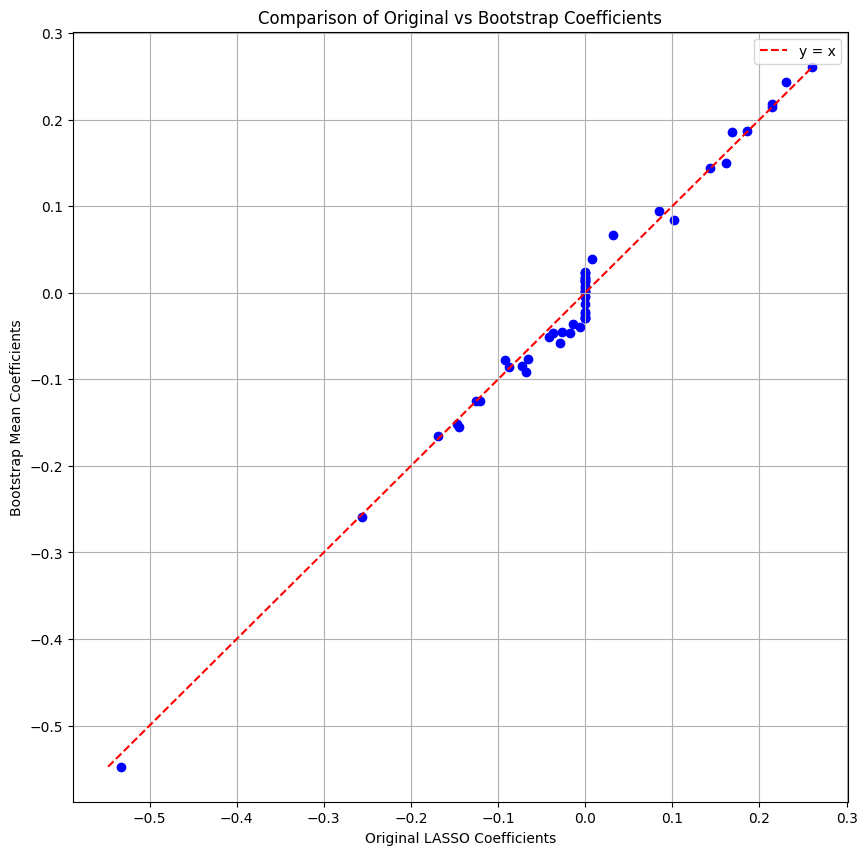

In [37]:
plt.figure(figsize=(10, 10))
plt.scatter(
    results_bootstrap_lasso_rounded["LASSO_coef"],
    results_bootstrap_lasso_rounded["Boot_mean"],
    color='blue'
)

max_val = max(results_bootstrap_lasso_rounded["LASSO_coef"].max(),
              results_bootstrap_lasso_rounded["Boot_mean"].max())
min_val = min(results_bootstrap_lasso_rounded["LASSO_coef"].min(),
              results_bootstrap_lasso_rounded["Boot_mean"].min())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x')

plt.xlabel("Original LASSO Coefficients")
plt.ylabel("Bootstrap Mean Coefficients")
plt.title("Comparison of Original vs Bootstrap Coefficients")
plt.legend()
plt.grid(True)
plt.show()

The points should be on the red line mostly. We can see that they are distributed quite well

We first applied the bootstrap to the coefficients, using resampled training sets to approximate their sampling distribution and obtain standard errors and confidence intervals. Having done that at the parameter level, we now apply the same idea to a performance metric, the AUC: by repeatedly resampling the test set and recomputing the AUC, we obtain not just a single value but an empirical distribution and a 95% confidence interval. This allows the evaluation to focus explicitly on uncertainty and variability in both the estimated effects and the predictive ability of the model, rather than relying only on point estimates.

In [38]:
# AUC on test
y_prob = result.predict(sm.add_constant(X_test))
auc = roc_auc_score(y_test, y_prob)

# bootstrap CI for AUC
aucs = []
for _ in range(1000):
    Xb, yb = resample(X_test, y_test, replace=True, stratify=y_test)
    pb = result.predict(sm.add_constant(Xb))
    aucs.append(roc_auc_score(yb, pb))
aucs = np.array(aucs)
print(f"AUC = {auc:.3f}, 95% CI [{np.percentile(aucs,2.5):.3f}, {np.percentile(aucs,97.5):.3f}]")

AUC = 0.750, 95% CI [0.680, 0.814]


The AUC of 0.75 with 95% CI [0.68, 0.81] indicates a moderately useful model, but far from excellent.

AUC Meaning
An AUC of 0.75 means the model correctly ranks a random good vs. bad client 75% of the time—better than random (0.5), but only modestly above 0.70, so discriminative power is moderate.

CI Interpretation
The [0.68, 0.81] range shows plausible AUCs from barely acceptable (~0.68) to good (~0.80), reflecting non-negligible uncertainty across samples of ~700 good/300 bad loans.

In short: informative risk ranking with moderate, variable performance—acknowledge limits in decisions.

## CROSS VALIDATION

Now we perform a cross‑validation study to investigate these bias–variance aspects. 
By comparing the average performance and its variability across folds for various models, we can see whether the unregularized model shows higher variance (more unstable scores) and whether the regularization created slightly lower fit but more stable, reliable out‑of‑sample performance.

In [39]:
k = 4
kf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

accuracies = []
f1_scores = []
recalls = []

for train_idx, test_idx in kf.split(X, y):
    X_train_cv, X_test_cv = X.iloc[train_idx], X.iloc[test_idx]
    y_train_cv, y_test_cv = y.iloc[train_idx], y.iloc[test_idx]

    # convert boolean to int if needed
    X_train_cv = X_train_cv.copy()
    X_test_cv  = X_test_cv.copy()
    X_train_cv[bool_cols] = X_train_cv[bool_cols].astype(int)
    X_test_cv[bool_cols]  = X_test_cv[bool_cols].astype(int)

    # statsmodels requires intercept manually
    X_train_cv_const = sm.add_constant(X_train_cv)
    X_test_cv_const  = sm.add_constant(X_test_cv)

    model_cv = sm.Logit(y_train_cv, X_train_cv_const)
    result_cv = model_cv.fit(disp=False)

    # predictions
    y_pred_prob = result_cv.predict(X_test_cv_const)
    y_pred = (y_pred_prob >= 0.5).astype(int)

    # metrics
    accuracies.append(accuracy_score(y_test_cv, y_pred))
    f1_scores.append(f1_score(y_test_cv, y_pred))
    recalls.append(recall_score(y_test_cv, y_pred))

print("Full Logit CV Accuracy:", round(np.mean(accuracies),3))
print("Full Logit CV F1-score:", round(np.mean(f1_scores),3))
print("Full Logit CV Recall:", round(np.mean(recalls),3))


df_models.loc["Logit Full", "CV Accuracy"] = round(np.mean(accuracies),3)
df_models.loc["Logit Full", "CV F1-score"] = round(np.mean(f1_scores),3)   
df_models.loc["Logit Full", "CV Recall"] = round(np.mean(recalls),3)

for i, (acc, f1, rec) in enumerate(zip(accuracies, f1_scores, recalls), start=1):
    print(f"Fold {i}: accuracy = {acc:.3f}, F1 = {f1:.3f}, recall_bad = {rec:.3f}")

Full Logit CV Accuracy: 0.742
Full Logit CV F1-score: 0.517
Full Logit CV Recall: 0.463
Fold 1: accuracy = 0.712, F1 = 0.446, recall_bad = 0.387
Fold 2: accuracy = 0.760, F1 = 0.583, recall_bad = 0.560
Fold 3: accuracy = 0.752, F1 = 0.523, recall_bad = 0.453
Fold 4: accuracy = 0.744, F1 = 0.515, recall_bad = 0.453


c:\Users\franc\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


The full logit model shows only mild variability in overall accuracy (from 0.71 to 0.76 across folds), but recall for bad credits is noticeably less stable, ranging from 0.39 to 0.56. This means the model’s ability to detect risky customers changes quite a bit depending on the sample, indicating relatively high variance exactly on the class we care most about.

In [40]:
accuracies_lim = []
f1_scores_lim = []
recall_scores_lim = []

for train_idx, test_idx in kf.split(X[X_limited], y):
    X_train_cv, X_test_cv = X[X_limited].iloc[train_idx], X[X_limited].iloc[test_idx]
    y_train_cv, y_test_cv = y.iloc[train_idx], y.iloc[test_idx]

    X_train_cv_const = sm.add_constant(X_train_cv)
    X_test_cv_const  = sm.add_constant(X_test_cv)

    model_cv_lim = sm.Logit(y_train_cv, X_train_cv_const)
    result_cv_lim = model_cv_lim.fit(disp=False)

    y_pred_prob = result_cv_lim.predict(X_test_cv_const)
    y_pred = (y_pred_prob >= 0.5).astype(int)

    accuracies_lim.append(accuracy_score(y_test_cv, y_pred))
    f1_scores_lim.append(f1_score(y_test_cv, y_pred))
    recall_scores_lim.append(recall_score(y_test_cv, y_pred))

print("Limited Logit CV Accuracy:", round(np.mean(accuracies_lim),3))
print("Limited Logit CV F1-score:", round(np.mean(f1_scores_lim),3))
print("Limited Logit CV Recall:", round(np.mean(recall_scores_lim),3))

df_models.loc["Logit Limited", "CV Accuracy"] = round(np.mean(accuracies_lim),3)
df_models.loc["Logit Limited", "CV F1-score"] = round(np.mean(f1_scores_lim),3)   
df_models.loc["Logit Limited", "CV Recall"] = round(np.mean(recall_scores_lim),3)

Limited Logit CV Accuracy: 0.771
Limited Logit CV F1-score: 0.556
Limited Logit CV Recall: 0.48


In [41]:
accuracies_cost = []
f1_scores_cost = []
recalls_cost = []

THRESH = 0.25

for train_idx, test_idx in kf.split(X, y):
    X_train_cv, X_test_cv = X.iloc[train_idx], X.iloc[test_idx]
    y_train_cv, y_test_cv = y.iloc[train_idx], y.iloc[test_idx]

    X_train_cv_const = sm.add_constant(X_train_cv)
    X_test_cv_const  = sm.add_constant(X_test_cv)

    model_cv = sm.Logit(y_train_cv, X_train_cv_const)
    result_cv = model_cv.fit(disp=False)

    y_pred_prob = result_cv.predict(X_test_cv_const)
    y_pred = (y_pred_prob >= THRESH).astype(int)

    accuracies_cost.append(accuracy_score(y_test_cv, y_pred))
    f1_scores_cost.append(f1_score(y_test_cv, y_pred))
    recalls_cost.append(recall_score(y_test_cv, y_pred))

print("Treshold Tuning CV Accuracy:", round(np.mean(accuracies_cost),3))
print("Treshold Tuning CV F1-score:", round(np.mean(f1_scores_cost),3))
print("Treshold Tuning CV Recall:", round(np.mean(recalls_cost),3))

df_models.loc["Treshold Tuning", "CV Accuracy"] = round(np.mean(accuracies_cost),3)
df_models.loc["Treshold Tuning", "CV F1-score"] = round(np.mean(f1_scores_cost),3)   
df_models.loc["Treshold Tuning", "CV Recall"] = round(np.mean(recalls_cost),3)

Treshold Tuning CV Accuracy: 0.694
Treshold Tuning CV F1-score: 0.592
Treshold Tuning CV Recall: 0.74


c:\Users\franc\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [42]:
acc_list_lasso = []
f1_list_lasso = []
recall_list_lasso = []

for train_idx, test_idx in kf.split(X, y):

    # split fold
    X_train_cv, X_test_cv = X.iloc[train_idx], X.iloc[test_idx]
    y_train_cv, y_test_cv = y.iloc[train_idx], y.iloc[test_idx]

    # re-scale inside fold
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_cv)
    X_test_scaled  = scaler.transform(X_test_cv)

    # LASSO logistic model
    lasso = LogisticRegression(
        penalty='l1',
        solver='liblinear',
        C=0.1,
        max_iter=10000
    )

    lasso.fit(X_train_scaled, y_train_cv)
    y_pred = lasso.predict(X_test_scaled)

    # metrics
    acc_list_lasso.append(accuracy_score(y_test_cv, y_pred))
    f1_list_lasso.append(f1_score(y_test_cv, y_pred))
    recall_list_lasso.append(recall_score(y_test_cv, y_pred, pos_label=1))

print("LASSO Logistic Regression CV Results")
print(f"Mean Accuracy: {np.mean(acc_list_lasso):.3f}")
print(f"Mean F1-score: {np.mean(f1_list_lasso):.3f}")
print(f"Mean Recall:   {np.mean(recall_list_lasso):.3f}")

df_models.loc["Lasso", "CV Accuracy"] = round(np.mean(acc_list_lasso),3)
df_models.loc["Lasso", "CV F1-score"] = round(np.mean(f1_list_lasso),3)   
df_models.loc["Lasso", "CV Recall"] = round(np.mean(recall_list_lasso),3)

for i, (acc, f1, rec) in enumerate(zip(acc_list_lasso,
                                       f1_list_lasso,
                                       recall_list_lasso), start=1):
    print(f"Fold {i}: accuracy = {acc:.3f}, F1 = {f1:.3f}, recall_bad = {rec:.3f}")

LASSO Logistic Regression CV Results
Mean Accuracy: 0.747
Mean F1-score: 0.484
Mean Recall:   0.400
Fold 1: accuracy = 0.724, F1 = 0.439, recall_bad = 0.360
Fold 2: accuracy = 0.768, F1 = 0.554, recall_bad = 0.480
Fold 3: accuracy = 0.740, F1 = 0.425, recall_bad = 0.320
Fold 4: accuracy = 0.756, F1 = 0.520, recall_bad = 0.440


Compared with the full logit, the Lasso model shows very similar accuracy but slightly lower and still quite variable recall on bad credits.

For the full logit, accuracy ranges from 0.71 to 0.76 and bad‑class recall from 0.39 to 0.56 across folds. For Lasso, accuracy ranges from 0.72 to 0.77 and recall from 0.32 to 0.48. This means Lasso does not reduce the instability on the bad class: it remains quite sensitive to the specific fold and, on average, detects slightly fewer bad clients than the full logit, even though overall accuracy is comparable.

Detected 4 folds from your previous loop.


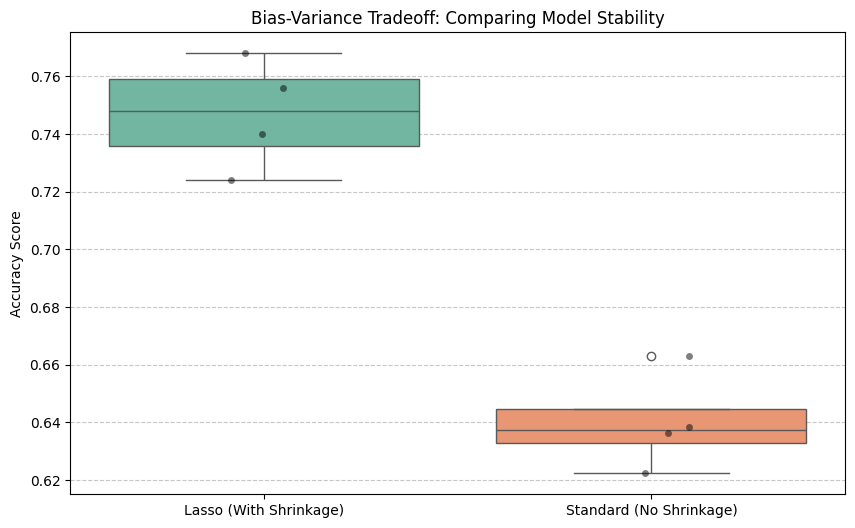

Lasso Mean:    0.747 | Std Dev: 0.017
Standard Mean: 0.640 | Std Dev: 0.015


In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Check how many folds you used in your manual loop
n_folds = len(acc_list_lasso) 
print(f"Detected {n_folds} folds from your previous loop.")

# 2. Run Standard Logistic Regression using the SAME number of folds
# We use a very high C (1e9) to effectively turn off regularization
standard_model = LogisticRegression(penalty='l2', C=1e9, solver='lbfgs', max_iter=10000)

# FIX: Set cv=n_folds so the lengths match exactly
scores_standard = cross_val_score(standard_model, X_train_scaled, y_train, cv=n_folds, scoring='accuracy')

# 3. Prepare the data
cv_data = pd.DataFrame({
    'Lasso (With Shrinkage)': acc_list_lasso,
    'Standard (No Shrinkage)': scores_standard
})

# 4. Create the Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=cv_data, palette="Set2")
sns.stripplot(data=cv_data, color='black', alpha=0.5, jitter=True) # Dots show the actual folds

plt.title('Bias-Variance Tradeoff: Comparing Model Stability')
plt.ylabel('Accuracy Score')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

# Print the comparison stats
print(f"Lasso Mean:    {np.mean(acc_list_lasso):.3f} | Std Dev: {np.std(acc_list_lasso):.3f}")
print(f"Standard Mean: {scores_standard.mean():.3f} | Std Dev: {scores_standard.std():.3f}")

**Cross-Validation Analysis: The Failure of the Standard Estimator**

We used **4-Fold Cross-Validation** to generate **4 independent performance scores** for each model. This allows us to assess not just the average accuracy, but the *stability* of that accuracy across different data samples.

**The boxplots above directly visualize these 4 cross-validation scores:**

### A. Interpreting the Spread (Variance)
* **The Dots:** Each individual point on the plot represents one of the 4 "folds" (a unique test set).
* **The Box:** The height of the box shows the variance. A tall box means the model's performance changes wildly depending on which clients are in the test set (Unstable). A short box means the model is consistent (Stable).

### B. Model Comparison (Lasso vs. Standard)
The visualization reveals a critical difference in how the models handle the data:

* **Standard Logistic Regression (Orange):**
    * **Performance:** The model collapses to a mean accuracy of **64.0%**.
    * **Diagnosis:** This is *worse* than the baseline (random guessing). The standard estimator fails to handle the correlations in the data, leading to a "degenerate" model that cannot generalize.
* **Lasso Logistic Regression (Green):**
    * **Performance:** By applying **L1 Regularization** (Shrinkage), the accuracy jumps to **74.7%**.
    * **Stability:** The tight grouping of the 4 scores (short box) proves that Regularization successfully stabilized the model, making it robust enough for banking applications.

Let's visualize the table for all the models metrics, single and CV 

In [43]:
df_models

,Test Accuracy,Test F1-score,Recall,CV Accuracy,CV F1-score,CV Recall
Logit Full,0.724,0.473,0.413,0.742,0.517,0.463
Logit Limited,0.752,0.500,0.413,0.771,0.556,0.480
Treshold Tuning,0.672,0.564,0.707,0.694,0.592,0.740
Lasso,0.772,0.537,0.440,0.747,0.484,0.400


These results suggest a clear trade‑off between overall accuracy and the ability to detect bad credits.

The full and limited logit models deliver solid accuracy on both test and CV (around 0.72–0.77) but relatively low recall on bad customers (about 0.41–0.48), meaning many risky clients remain undetected. The Lasso model slightly improves test accuracy to 0.77 with comparable CV accuracy (0.75), but its recall on bads is still modest (≈0.44), confirming that regularization mainly helps interpretability and stability rather than sensitivity to defaults. The threshold‑tuned model, instead, sacrifices accuracy (test ≈0.67, CV ≈0.69) to achieve much higher recall on bad credits (around 0.70–0.74), which best matches the business objective of minimizing undetected bad loans.​

These results highlight useful patterns but also come with clear limitations.

Model limits
The models are all linear in the log‑odds, so they may miss nonlinear or interaction effects between variables, which could improve default detection.

Performance is evaluated on a single train–test split and 4‑fold CV; with only 75 bad clients, estimates of recall for the bad class remain noisy and somewhat unstable.

Data and evaluation limits
The German Credit dataset is relatively small and historical, so the models may not fully generalize to current portfolios or different economic conditions.

Class weights and misclassification costs are not explicitly modeled; in reality, the cost of missing a bad client is much higher than wrongly rejecting a good one, which suggests that more formal cost‑sensitive methods could be explored beyond simple threshold tuning.

C:\Users\franc\AppData\Local\Temp\ipykernel_22112\519787086.py:12: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(y_probs[y_test_cv == 0], shade=True, color='green', label='Actual Good Credit (Class 0)')
C:\Users\franc\AppData\Local\Temp\ipykernel_22112\519787086.py:15: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(y_probs[y_test_cv == 1], shade=True, color='red', label='Actual Bad Credit (Class 1)')


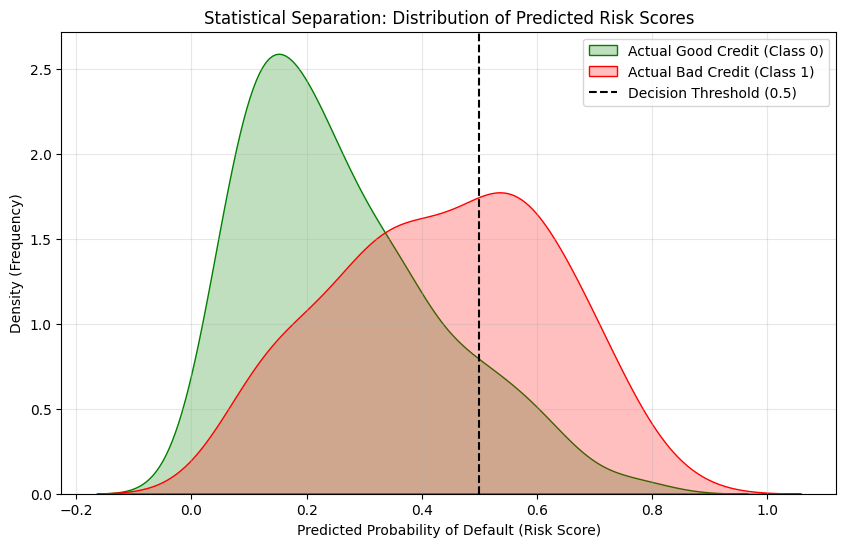

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get the predicted probabilities (Risk Scores) for the test set
# We use the probabilities for Class 1 (Bad Credit)
y_probs = lasso.predict_proba(X_test_scaled)[:, 1]

# 2. Plot the Densities (Distributions)
plt.figure(figsize=(10, 6))

# Plot distribution for Actual Good Credit (y=0)
sns.kdeplot(y_probs[y_test_cv == 0], shade=True, color='green', label='Actual Good Credit (Class 0)')

# Plot distribution for Actual Bad Credit (y=1)
sns.kdeplot(y_probs[y_test_cv == 1], shade=True, color='red', label='Actual Bad Credit (Class 1)')

# Add a threshold line (usually 0.5)
plt.axvline(0.5, color='black', linestyle='--', label='Decision Threshold (0.5)')

plt.title('Statistical Separation: Distribution of Predicted Risk Scores')
plt.xlabel('Predicted Probability of Default (Risk Score)')
plt.ylabel('Density (Frequency)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Analysis of Population Separation (Lasso Model)**

To further investigate the properties of our **Final Chosen Model (Lasso)**, we visualize the **Empirical Densities** of the predicted risk scores.

### A. Interpretation of the Distributions
This graph visualizes the **Discriminant Power** of the Lasso Logistic Regression:

* **Green Curve (Good Credit):** The distribution is **tall and narrow** (Low Variance), peaking around 0.2. This indicates the Lasso model detects a strong, consistent signal for "Good" applicants.
* **Red Curve (Bad Credit):** The distribution is **flat and wide** (High Variance), spreading from 0.3 to 0.8. This suggests that "Bad" applicants are more heterogeneous—there is no single "profile" of a defaulter.

### B. The "Statistical Overlap" (Source of Error)
The overlapping area between the two curves represents the **Bayes Error Rate** (the irreducible error) of the dataset.
* **The Conflict:** In the score range of **0.30 – 0.60**, the probability of a client being Good or Bad is nearly equal.
* **Implication:** This overlap confirms that while the Lasso model captures the primary risk factors, the financial behavior of clients in this "middle zone" is mathematically indistinguishable based on the available data.